In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [6]:
BASE_PATH = Path(r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images")

UPPER_GI = BASE_PATH / "upper-gi-tract"
LOWER_GI = BASE_PATH / "lower-gi-tract"

print("Upper GI Path:", UPPER_GI)
print("Lower GI Path:", LOWER_GI)

Upper GI Path: C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract
Lower GI Path: C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\lower-gi-tract


In [7]:
for root, dirs, files in os.walk(UPPER_GI):
    print(root)

C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract
C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract\anatomical-landmarks
C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract\anatomical-landmarks\pylorus
C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract\anatomical-landmarks\retroflex-stomach
C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract\anatomical-landmarks\z-line
C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract\pathological-findings
C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract\pathological-findings\barretts
C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract\pathological-findings\barretts-short-segment
C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract\pathological-findings\esophagitis-a
C:\Users\ADMIN\Desktop\Projects\Cancer

In [9]:
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# =========================================================
# Base Paths
# =========================================================

BASE_PATH = Path(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\labeled-images\upper-gi-tract"
)

OUTPUT_PATH = Path(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\classification"
)

# =========================================================
# Class Mapping
# =========================================================

NORMAL_CLASSES = [
    "pylorus",
    "retroflex-stomach",
    "z-line"
]

ABNORMAL_CLASSES = [
    "barretts",
    "barretts-short-segment",
    "esophagitis-a",
    "esophagitis-b-d"
]

# =========================================================
# Collect Images
# =========================================================

normal_images = []
abnormal_images = []

for class_name in NORMAL_CLASSES:

    class_path = list(BASE_PATH.rglob(class_name))[0]

    images = list(class_path.glob("*.jpg"))

    normal_images.extend(images)

for class_name in ABNORMAL_CLASSES:

    class_path = list(BASE_PATH.rglob(class_name))[0]

    images = list(class_path.glob("*.jpg"))

    abnormal_images.extend(images)

print(f"Normal Images: {len(normal_images)}")
print(f"Abnormal Images: {len(abnormal_images)}")

# =========================================================
# Train / Val / Test Split Function
# =========================================================

def split_data(images):

    train, temp = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    val, test = train_test_split(
        temp,
        test_size=0.50,
        random_state=42
    )

    return train, val, test

# =========================================================
# Split Data
# =========================================================

normal_train, normal_val, normal_test = split_data(normal_images)

abnormal_train, abnormal_val, abnormal_test = split_data(abnormal_images)

# =========================================================
# Copy Function
# =========================================================

def copy_images(image_list, destination):

    destination.mkdir(parents=True, exist_ok=True)

    for image_path in image_list:

        shutil.copy(image_path, destination / image_path.name)

# =========================================================
# Copy Normal Images
# =========================================================

copy_images(
    normal_train,
    OUTPUT_PATH / "train" / "normal"
)

copy_images(
    normal_val,
    OUTPUT_PATH / "val" / "normal"
)

copy_images(
    normal_test,
    OUTPUT_PATH / "test" / "normal"
)

# =========================================================
# Copy Abnormal Images
# =========================================================

copy_images(
    abnormal_train,
    OUTPUT_PATH / "train" / "abnormal"
)

copy_images(
    abnormal_val,
    OUTPUT_PATH / "val" / "abnormal"
)

copy_images(
    abnormal_test,
    OUTPUT_PATH / "test" / "abnormal"
)

print("\n✅ Classification dataset prepared successfully!")

Normal Images: 2695
Abnormal Images: 757

✅ Classification dataset prepared successfully!


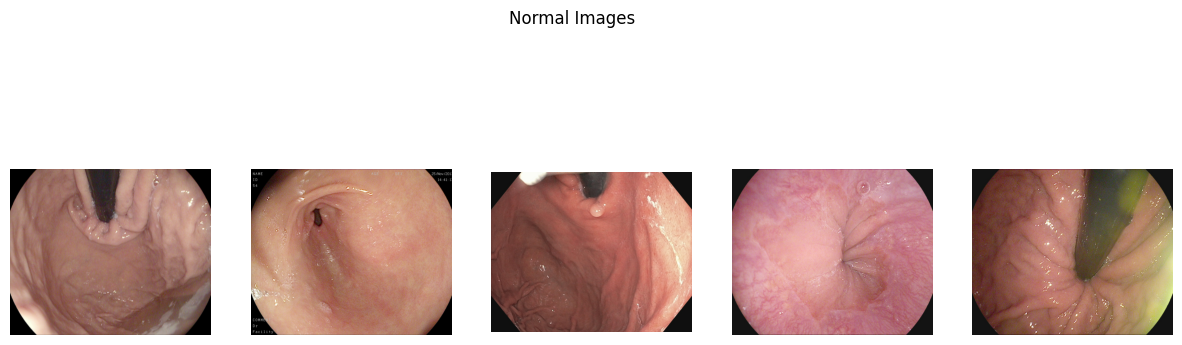

In [10]:
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path

normal_path = Path(
    "../../dataset/classification/train/normal"
)

images = list(normal_path.glob("*.jpg"))

sample_images = random.sample(images, 5)

plt.figure(figsize=(15,5))

for idx, image_path in enumerate(sample_images):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,idx+1)
    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Normal Images")
plt.show()

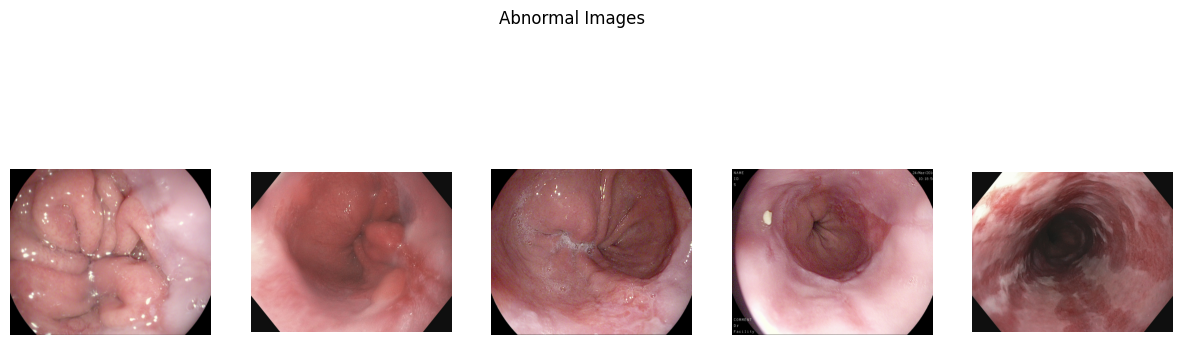

In [11]:
abnormal_path = Path(
    "../../dataset/classification/train/abnormal"
)

images = list(abnormal_path.glob("*.jpg"))

sample_images = random.sample(images, 5)

plt.figure(figsize=(15,5))

for idx, image_path in enumerate(sample_images):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,idx+1)
    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Abnormal Images")
plt.show()

In [12]:
sizes = []

for image_path in normal_path.glob("*.jpg"):

    image = cv2.imread(str(image_path))

    h, w = image.shape[:2]

    sizes.append((w, h))

sizes[:10]

[(1349, 1071),
 (1349, 1071),
 (1194, 1008),
 (1221, 1011),
 (1349, 1071),
 (1195, 1015),
 (1349, 1071),
 (1221, 1020),
 (1349, 1071),
 (1349, 1071)]